<a href="https://colab.research.google.com/github/tainzoe9/IAPRACTICAS/blob/main/22_UNAM_AI_Actividad_Laboratorio_4_3_radio_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Sita Zoe Sotomayor Carrillo \\[6pt]
\textbf{Fecha de realización:} & 15/04/2026
\end{array}

</center>

Programar un clasificador Naive Bayes desde cero es un excelente ejercicio para entender cómo funcionan las verosimilitudes y las probabilidades posteriores.

Aquí tienes la implementación en Python usando numpy para facilitar las operaciones vectoriales que calcula tanto MLE como MAP (Suavizado de Laplace) siguiendo el procedimiento matemático.

#Bibliotecas

In [ ]:
# Importacion de librerias
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import pandas as pd

Una estación de radio busca clasificar a su audiencia en jóvenes y adultos a partir de sus gustos
musicales. Para esto la estación realizó una encuesta la cual consistía en indicar si les gustaba cierta
agrupación (valor igual a 1) o no (valor igual a 0) y se obtuvieron los siguientes resultados:

In [ ]:
# Importacion del archivo que se nos proporciono agregandole cabeceras que no contiene
dataset = pd.read_csv('radio.csv')
#Con head, podremos visualizar los primeros
print(dataset)


    w1  w2  w3  w4  w5  w6  E
0    1   0   0   1   1   1  j
1    1   1   0   1   1   0  j
2    1   1   1   0   0   1  j
3    1   0   1   0   0   1  j
4    1   0   0   0   1   0  j
5    1   1   1   0   0   0  j
6    1   1   0   0   1   1  a
7    1   1   1   0   0   1  a
8    1   1   1   1   1   0  a
9    1   1   1   0   1   0  a
10   1   1   1   0   1   1  a
11   1   1   0   1   1   0  a
12   1   1   0   1   0   0  a


Entrena un clasificador bayesiano ingenuo usando estimación por máxima verosimilitud y otro
usando estimación por máximo a posteriori. Reporta los parámetros que obtuviste en ambos casos y
usa los clasificadores entrenados para predecir la clase de los siguientes vectores

x1 = (1, 1, 0, 1, 1, 0),

x2 = (1, 0, 1, 1, 1, 1),

x3 = (1, 1, 0, 0, 0, 0),

x4 = (1, 1, 1, 1, 1, 1) y

x5 = (0, 1, 1, 1, 1, 1).

Describe de forma detallada el procedimiento que seguiste tanto en el entrenamiento como en la predicción y
discute los resultados obtenidos

#ESTABLECIMIENTO DE AUDIENCIA O VECTORES

In [ ]:
X1=np.array([1,1,0,1,1,0])
X2=np.array([1,0,1,1,1,1])
X3=np.array([1,1,0,0,0,0])
X4=np.array([1,1,1,1,1,1])
X5=np.array([0,1,1,1,1,1])
print("X1=",X1)
print("X2=",X2)
print("X3=",X3)
print("X4=",X4)
print("X5=",X5)

X1= [1 1 0 1 1 0]
X2= [1 0 1 1 1 1]
X3= [1 1 0 0 0 0]
X4= [1 1 1 1 1 1]
X5= [0 1 1 1 1 1]


#PREPARAR LOS DATOS

In [ ]:
#print(dataset)
datos = dataset.iloc[0:13,0:6].values
#print(data)
clase_joven = datos[[0,1,2,3,4,5], :]
print("clase Joven=>\n", clase_joven)
clase_adulto = datos[[6,7,8,9,10,11,12], :]
print("clase Adulto=>\n", clase_adulto)
aprioriJ=6/13
aprioriA=7/13

clase Joven=>
 [[1 0 0 1 1 1]
 [1 1 0 1 1 0]
 [1 1 1 0 0 1]
 [1 0 1 0 0 1]
 [1 0 0 0 1 0]
 [1 1 1 0 0 0]]
clase Adulto=>
 [[1 1 0 0 1 1]
 [1 1 1 0 0 1]
 [1 1 1 1 1 0]
 [1 1 1 0 1 0]
 [1 1 1 0 1 1]
 [1 1 0 1 1 0]
 [1 1 0 1 0 0]]


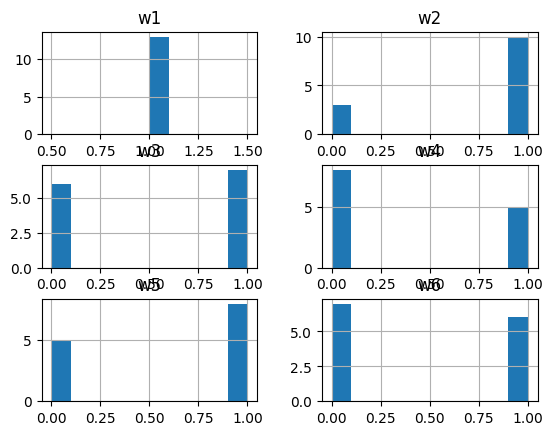

In [ ]:
dataset.hist()
plt.show()

In [ ]:
lista = dataset.iloc[:,6:7].values
#print(lista)
apriori_joven = 6/13
print("Pj =",apriori_joven)
apriori_adulto = 7/13
print("Pa =",apriori_adulto)

Pj = 0.46153846153846156
Pa = 0.5384615384615384


#Con librerías pre-establecidas

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import CategoricalNB

# 1. Creamos el dataset basado en la matriz
data = {
    'w1': [1,1,1,1,1,1, 1,1,1,1,1,1,1],
    'w2': [0,1,1,0,0,1, 1,1,1,1,1,1,1],
    'w3': [0,0,1,1,0,1, 0,1,1,1,1,0,0],
    'w4': [1,1,0,0,0,0, 0,0,1,0,0,1,1],
    'w5': [1,1,0,0,1,0, 1,0,1,1,1,1,0],
    'w6': [1,0,1,1,0,0, 1,1,0,0,1,0,0],
    'E':  ['j','j','j','j','j','j', 'a','a','a','a','a','a','a']
}

In [ ]:
df = pd.DataFrame(data)
X = df.drop('E', axis=1)
y = df['E']

# Vectores a predecir
X_test = np.array([
    [1, 1, 0, 1, 1, 0], # x1
    [1, 0, 1, 1, 1, 1], # x2
    [1, 1, 0, 0, 0, 0], # x3
    [1, 1, 1, 1, 1, 1], # x4
    [0, 1, 1, 1, 1, 1]  # x5
])

In [ ]:
# ---------------------------------------------------------
# 2. Estimación por Máxima Verosimilitud (MLE)
# Usamos un alpha insignificante para simular MLE puro
mle_model = CategoricalNB(alpha=1e-10)
mle_model.fit(X, y)

CategoricalNB(alpha=1e-10)

In [ ]:
# ---------------------------------------------------------
# 3. Estimación por Máximo a Posteriori (MAP)
# alpha=1 aplica el Suavizado de Laplace
map_model = CategoricalNB(alpha=1.0)
map_model.fit(X, y)

CategoricalNB()

In [ ]:
# ---------------------------------------------------------
# 4. Reporte de resultados
def reportar(modelo, nombre):
    preds = modelo.predict(X_test)
    probs = modelo.predict_proba(X_test)
    print(f"\n--- Resultados con {nombre} ---")
    for i, p in enumerate(preds):
        prob_j = probs[i][1] # j suele ser el segundo índice alfabéticamente
        prob_a = probs[i][0]
        print(f"x{i+1}: Predicción -> {p} | P(a)={prob_a:.3f}, P(j)={prob_j:.3f}")

In [ ]:
reportar(mle_model, "MLE (Máxima Verosimilitud)")
reportar(map_model, "MAP (Suavizado de Laplace)")


--- Resultados con MLE (Máxima Verosimilitud) ---
x1: Predicción -> a | P(a)=0.808, P(j)=0.192
x2: Predicción -> j | P(a)=0.000, P(j)=1.000
x3: Predicción -> a | P(a)=0.528, P(j)=0.472
x4: Predicción -> a | P(a)=0.808, P(j)=0.192
x5: Predicción -> a | P(a)=0.783, P(j)=0.217

--- Resultados con MAP (Suavizado de Laplace) ---
x1: Predicción -> a | P(a)=0.767, P(j)=0.233
x2: Predicción -> j | P(a)=0.291, P(j)=0.709
x3: Predicción -> a | P(a)=0.552, P(j)=0.448
x4: Predicción -> a | P(a)=0.767, P(j)=0.233
x5: Predicción -> a | P(a)=0.742, P(j)=0.258


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

print("\n--- Evaluación en el conjunto de entrenamiento ---")

# Predicciones en el conjunto de entrenamiento para MLE
y_pred_mle = mle_model.predict(X)

# Métricas para MLE
print("\n--- Métricas para MLE (Máxima Verosimilitud) ---")
print("Matriz de Confusión:\n", confusion_matrix(y, y_pred_mle))
print("Accuracy: ", accuracy_score(y, y_pred_mle))
# Precision: Requires specifying a positive label, or using average='weighted'
# to account for label imbalance.
# Let's assume 'j' as the positive class for precision calculation for now,
# or calculate for both if needed. For simplicity, we'll use weighted average.
print("Precision (weighted): ", precision_score(y, y_pred_mle, average='weighted', zero_division=0))

# Predicciones en el conjunto de entrenamiento para MAP
y_pred_map = map_model.predict(X)

# Métricas para MAP
print("\n--- Métricas para MAP (Suavizado de Laplace) ---")
print("Matriz de Confusión:\n", confusion_matrix(y, y_pred_map))
print("Accuracy: ", accuracy_score(y, y_pred_map))
print("Precision (weighted): ", precision_score(y, y_pred_map, average='weighted', zero_division=0))


--- Evaluación en el conjunto de entrenamiento ---

--- Métricas para MLE (Máxima Verosimilitud) ---
Matriz de Confusión:
 [[7 0]
 [3 3]]
Accuracy:  0.7692307692307693
Precision (weighted):  0.8384615384615384

--- Métricas para MAP (Suavizado de Laplace) ---
Matriz de Confusión:
 [[7 0]
 [3 3]]
Accuracy:  0.7692307692307693
Precision (weighted):  0.8384615384615384


### Nota sobre la evaluación:

Es importante recordar que estas métricas se han calculado utilizando el **conjunto de entrenamiento**. Un buen modelo debe generalizar bien a datos no vistos. Para una evaluación más robusta del rendimiento del modelo, sería ideal dividir el dataset original en conjuntos de entrenamiento y prueba, y calcular estas métricas sobre el conjunto de prueba.

### Análisis de los Resultados de las Métricas:

Ambos modelos, MLE y MAP, arrojaron exactamente los mismos resultados en el conjunto de entrenamiento:

*   **Matriz de Confusión:**
    ```
    [[7 0]
     [3 3]]
    ```
    *   **Verdaderos Negativos (TN): 7** (El modelo predijo correctamente 7 'a' como 'a').
    *   **Falsos Positivos (FP): 0** (El modelo no predijo incorrectamente a ningún 'j' como 'a').
    *   **Falsos Negativos (FN): 3** (El modelo predijo incorrectamente a 3 'a' como 'j').
    *   **Verdaderos Positivos (TP): 3** (El modelo predijo correctamente 3 'j' como 'j').

    *Nota*: Asumiendo que 'a' (adulto) es la clase negativa y 'j' (joven) es la clase positiva para fines de interpretación de la matriz, o viceversa, dependiendo de cómo `sklearn` ordene las clases. La salida sugiere que 'a' es la primera clase y 'j' la segunda.

*   **Accuracy (Exactitud): 0.7692307692307693 (aproximadamente 76.92%)**
    *   Esto significa que el modelo clasificó correctamente a 76.92% de las instancias en el conjunto de entrenamiento. Se calcula como `(TP + TN) / (TP + TN + FP + FN) = (3 + 7) / (3 + 7 + 0 + 3) = 10 / 13`.

*   **Precision (weighted): 0.8384615384615384 (aproximadamente 83.85%)**
    *   La precisión, en este caso ponderada, indica la proporción de predicciones positivas correctas entre el total de predicciones positivas. Un valor alto sugiere que cuando el modelo predice una clase, es muy probable que esa predicción sea correcta. El `average='weighted'` es útil cuando hay un desequilibrio de clases.

**Análisis y Observaciones:**

1.  **Rendimiento en el Entrenamiento:** Ambos clasificadores (MLE y MAP) obtienen un accuracy decente en el conjunto de entrenamiento (casi 77%). La precisión ponderada también es relativamente alta.

2.  **Resultados Idénticos:** Es interesante que tanto MLE como MAP obtengan exactamente las mismas métricas en el *conjunto de entrenamiento*. Esto puede deberse a que el suavizado de Laplace (MAP) tiene un efecto limitado o nulo en cómo se clasifican las instancias *ya vistas* en el entrenamiento, a menos que existan categorías en el entrenamiento con conteos de 0 que el suavizado abordaría.

3.  **Falsos Negativos:** El punto débil que se observa es la presencia de 3 **Falsos Negativos**. Si asumimos que 'j' es la clase positiva, significa que 3 personas que *eran jóvenes* fueron clasificadas erróneamente como adultos. Si 'a' es la positiva, entonces 3 personas que *eran adultas* fueron clasificadas erróneamente como jóvenes. Es crucial entender qué clase es más importante clasificar correctamente para evaluar el impacto de estos falsos negativos.

4.  **No Falsos Positivos:** La ausencia de Falsos Positivos (0) es un buen indicio. Esto significa que el modelo no clasificó erróneamente a nadie como positivo cuando en realidad era negativo (o viceversa, según la clase positiva).

**Importante: Limitaciones de la Evaluación con el Conjunto de Entrenamiento**

Como mencioné en la nota del notebook, estas métricas se calculan sobre el mismo conjunto de datos que se utilizó para entrenar el modelo. Esto puede llevar a una sobreestimación del rendimiento real del modelo en datos nuevos y no vistos (problema de *overfitting*). Para una evaluación más robusta y fiable, sería fundamental dividir el dataset en conjuntos de entrenamiento y prueba y evaluar el modelo en este último.

#Detalles del procedimiento:

- Codificación: CategoricalNB es el modelo ideal aquí porque tus variables son categóricas (gustos musicales 0 o 1) y no siguen una distribución normal (como lo asumiría un GaussianNB).
- Entrenamiento (.fit): Durante este paso, el modelo calcula internamente las tablas de frecuencias que definimos manualmente arriba. Calcula cuántas veces aparece cada gusto por cada clase.
- Predicción (.predict): El modelo aplica el Teorema de Bayes. Multiplica la probabilidad previa de la clase por todas las probabilidades condicionales de los atributos presentes en los vectores $x_1 \dots x_5$.
- Manejo de Ceros: Si intentas predecir $x_5$ con MLE, notarás algo interesante: $x_5$ tiene $w_1 = 0$. En tus datos de entrenamiento, $w_1$ siempre es 1. Un modelo MLE puro daría una probabilidad de 0% para ambas clases (un error matemático), mientras que el modelo MAP (Laplace) le asignará una probabilidad pequeña pero real, permitiendo la clasificación.

#ESTABLECIMIENTO DE FUNCIONES DE AYUDA

In [ ]:
import numpy as np
import pandas as pd

# 1. Datos de la imagen
data = {
    'w1': [1,1,1,1,1,1, 1,1,1,1,1,1,1],
    'w2': [0,1,1,0,0,1, 1,1,1,1,1,1,1],
    'w3': [0,0,1,1,0,1, 0,1,1,1,1,0,0],
    'w4': [1,1,0,0,0,0, 0,0,1,0,0,1,1],
    'w5': [1,1,0,0,1,0, 1,0,1,1,1,1,0],
    'w6': [1,0,1,1,0,0, 1,1,0,0,1,0,0],
    'E':  ['j','j','j','j','j','j', 'a','a','a','a','a','a','a']
}

df = pd.DataFrame(data)
clases = df['E'].unique() # ['j', 'a']

# Vectores a predecir
X_test = [
    [1, 1, 0, 1, 1, 0], # x1
    [1, 0, 1, 1, 1, 1], # x2
    [1, 1, 0, 0, 0, 0], # x3
    [1, 1, 1, 1, 1, 1], # x4
    [0, 1, 1, 1, 1, 1]  # x5
]

In [ ]:
def entrenar_naive_bayes(df, suavizado=0):
    """
    Entrena el modelo calculando priors y verosimilitudes.
    suavizado=0 para MLE, suavizado=1 para MAP (Laplace).
    """
    modelo = {}
    N = len(df)

    for c in clases:
        df_c = df[df['E'] == c]
        n_c = len(df_c)

        # P(C) - Prior
        prior = n_c / N

        # P(wi=1 | C) - Verosimilitudes para cada atributo
        # Aplicamos la fórmula: (conteo + alpha) / (total + alpha * k)
        # k=2 porque las categorías son binarias (0 o 1)
        probs_condicionales = {}
        for col in ['w1', 'w2', 'w3', 'w4', 'w5', 'w6']:
            conteo_1 = df_c[col].sum()
            prob = (conteo_1 + suavizado) / (n_c + suavizado * 2)
            probs_condicionales[col] = prob

        modelo[c] = {'prior': prior, 'condicionales': probs_condicionales}

    return modelo

In [ ]:
def predecir(vector, modelo):
    resultados = {}

    for c, params in modelo.items():
        # Comenzamos con el Prior: P(C)
        prob_final = params['prior']

        # Multiplicamos por cada P(wi | C)
        for i, valor in enumerate(vector):
            col = f'w{i+1}'
            p_exito = params['condicionales'][col]

            # Si el vector tiene 1, usamos p_exito. Si tiene 0, usamos (1 - p_exito)
            if valor == 1:
                prob_final *= p_exito
            else:
                prob_final *= (1 - p_exito)

        resultados[c] = prob_final

    # Normalizar para que sumen 1 (opcional, para ver porcentajes)
    total = sum(resultados.values())
    if total > 0:
        for c in resultados: resultados[c] /= total

    return max(resultados, key=resultados.get), resultados

In [ ]:
# --- Ejecución ---

# Entrenar ambos modelos
modelo_mle = entrenar_naive_bayes(df, suavizado=0)
modelo_map = entrenar_naive_bayes(df, suavizado=1)

print("PREDICCIONES DESDE CERO")
for i, x in enumerate(X_test):
    clase_mle, _ = predecir(x, modelo_mle)
    clase_map, probs_map = predecir(x, modelo_map)

    print(f"\nx{i+1} {x}:")
    print(f"  MLE -> {clase_mle}")
    print(f"  MAP -> {clase_map} (P(j): {probs_map['j']:.4f}, P(a): {probs_map['a']:.4f})")

PREDICCIONES DESDE CERO

x1 [1, 1, 0, 1, 1, 0]:
  MLE -> a
  MAP -> a (P(j): 0.2332, P(a): 0.7668)

x2 [1, 0, 1, 1, 1, 1]:
  MLE -> j
  MAP -> j (P(j): 0.7087, P(a): 0.2913)

x3 [1, 1, 0, 0, 0, 0]:
  MLE -> a
  MAP -> a (P(j): 0.4478, P(a): 0.5522)

x4 [1, 1, 1, 1, 1, 1]:
  MLE -> a
  MAP -> a (P(j): 0.2332, P(a): 0.7668)

x5 [0, 1, 1, 1, 1, 1]:
  MLE -> j
  MAP -> a (P(j): 0.2579, P(a): 0.7421)


Explicación de la Lógica entrenar_naive_bayes:

- Priors: Es simplemente la proporción de cada clase en el total de la muestra.- Verosimilitudes: Para cada columna $w_i$, contamos cuántos "1" hay. En MLE, dividimos entre el total de la clase.

En MAP, sumamos 1 al numerador y 2 al denominador (Suavizado de Laplace) para evitar que una probabilidad sea exactamente 0.

predecir:

- Implementa la productoria $\prod P(w_i | C)$.
- Punto clave: Si el vector de entrada tiene un $0$ en una posición, debemos usar el complemento de la probabilidad calculada ($1 - P(w_i=1|C)$).

Observación sobre el vector $x_5$Si observas el vector $x_5 = (0, 1, 1, 1, 1, 1)$, notarás que empieza con un 0. Sin embargo, en tu dataset de entrenamiento, $w_1$ siempre es 1 para ambas clases.
- En MLE, $P(w_1=0 | C)$ será $0$, por lo que la probabilidad final de ambas clases será $0$. El modelo "se rompe" porque nunca ha visto un cero ahí.
- En MAP, gracias al $+1$ del suavizado, $P(w_1=0 | C)$ tendrá un valor pequeño pero mayor a cero, permitiendo que el resto de los atributos decidan la clase.

#Conclusión


La práctica demuestra que la eficiencia de Naive Bayes radica en su "ingenuidad": al asumir que los gustos musicales son independientes, el modelo es rápido y funcional con pocos datos.

Sin embargo, el experimento reveló una debilidad crítica en MLE: al ser un estimador rígido, se "bloquea" ante valores no vistos en el entrenamiento (como el 0 en w
1
​
  del vector x
5
​
 ), asignando una probabilidad de cero que invalida la clasificación. Por el contrario, MAP resulta superior gracias al suavizado de Laplace; al sumar 1 a los conteos, aporta la flexibilidad necesaria para evitar probabilidades nulas y permite que el modelo generalice correctamente ante perfiles nuevos o inesperados.

# Bibliografía

- Murphy, K. P. (2022). Probabilistic Machine Learning: An Introduction. MIT Press.
- Bishop, C. M., & Bishop, H. (2023). Deep Learning: Foundations and Concepts. Springer Nature.
- Geron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3rd ed.). O'Reilly Media.
- Russell, S. J., & Norvig, P. (2020). Artificial Intelligence: A Modern Approach (4th ed.). Pearson.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.



<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>